# 05_01 LightGBM architecture comparison

Compare four global LightGBM architectures—daily L2, daily Tweedie, two-stage occurrence × positive quantity, and a seven-day total Tweedie model followed by historical weekday allocation—against the primary benchmark from `03_01` and all extended baselines from `04_01`. Every model is evaluated on the same series, weekly origins, seven-day horizon, and target rows.

## Shared design

The target is `ABVERKAUFTE_MENGE_KG`. The test contains 20 weekly origins, with forecasts and origin-specific features produced every seven days. The first refit uses 48 weekly training origins and the next four completed origins for validation and early stopping. One fitted model forecasts the next four weekly test origins. At each 28-day refit, the previous validation origins enter the expanding training set and the latest four completed origins become validation.

Demand-history features are strictly pre-origin. The known action schedule contributes `action_on_forecast_day` and `action_during_horizon`; `days_since_last_action`, the count `actions_last_28d`, and `mean_action_lift_in_sourcing_group` use only observations before the origin. The sourcing-group lift is the historical mean demand on action rows divided by the mean on non-action rows, minus one. ADI, CV², demand-gap measures, and annual-history signals are numeric features; FCM/Pseudo and 890/900 remain identifier features and reporting segments. The weekly model is trained on series-origin totals and its daily allocations sum exactly to the predicted seven-day total.

The comparison keeps the model roles separate: `PRIMARY_MODEL` is the fixed benchmark selected in `03_01`; `BASELINE_MODEL_LABELS` contains the extended statistical baselines evaluated in `04_01`; and the best non-ML reference is selected only from those prespecified candidates.

The training window begins with 48 origins and expands by four origins at each 28-day refit; the four-origin validation window always contains the latest completed origins. The fitted booster stays fixed for four forecast weeks, while a new feature snapshot is generated at each weekly origin using all information available strictly before that origin. Within each seven-day horizon, predictions are direct and are not fed recursively into later target days.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/ba-matplotlib')

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import (
    BASELINE_MODEL_LABELS, MODEL_COLUMNS, PRIMARY_MODEL,
    load_benchmark_design, segment_wape, summarize_models,
)
from src.models.lightgbm import (
    LIGHTGBM_MODEL_LABELS, MODEL_NAME, TARGET_COLUMN,
    TWEEDIE_MODEL_NAME, TWO_STAGE_MODEL_NAME, WEEKLY_MODEL_NAME,
)
from src.models.results import load_benchmark_result, load_lightgbm_results

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 160)
sns.set_theme(style='whitegrid', context='notebook')


In [2]:
design = load_benchmark_design()
print(f'Target: {TARGET_COLUMN}')
display(pd.DataFrame([design.__dict__]))

print("Loading benchmark results...")
benchmark = load_benchmark_result(design, include_extended_baselines=True)
print("Loaded benchmark")
print("Loading l2 results...")
lightgbm_l2_result = load_lightgbm_results(design, [MODEL_NAME])[MODEL_NAME]
print("Loading tweedie results...")
lightgbm_tweedie_result = load_lightgbm_results(
    design, [TWEEDIE_MODEL_NAME],
)[TWEEDIE_MODEL_NAME]
print("Loading two stage results...")
lightgbm_two_stage_result = load_lightgbm_results(
    design, [TWO_STAGE_MODEL_NAME],
)[TWO_STAGE_MODEL_NAME]
print("Loading weekly total results...")
lightgbm_weekly_total_result = load_lightgbm_results(
    design, [WEEKLY_MODEL_NAME],
)[WEEKLY_MODEL_NAME]

def prepare_forecast_frame(frame):
    prepared = frame.loc[frame['is_active']].copy()
    prepared['business_segment'] = (
        prepared.sourcing_group + ' ' + prepared.category_id.astype(str)
    )
    return prepared

benchmark_forecasts = prepare_forecast_frame(benchmark.forecasts)
lightgbm_l2_forecasts = prepare_forecast_frame(lightgbm_l2_result.forecasts)
lightgbm_tweedie_forecasts = prepare_forecast_frame(
    lightgbm_tweedie_result.forecasts
)
lightgbm_two_stage_forecasts = prepare_forecast_frame(
    lightgbm_two_stage_result.forecasts
)
lightgbm_weekly_total_forecasts = prepare_forecast_frame(
    lightgbm_weekly_total_result.forecasts
)
ML_MODELS = list(LIGHTGBM_MODEL_LABELS)
ML_FORECAST_FRAMES = {
    MODEL_NAME: lightgbm_l2_forecasts,
    TWEEDIE_MODEL_NAME: lightgbm_tweedie_forecasts,
    TWO_STAGE_MODEL_NAME: lightgbm_two_stage_forecasts,
    WEEKLY_MODEL_NAME: lightgbm_weekly_total_forecasts,
}
lightgbm_l2_training_summary = lightgbm_l2_result.training_summary
lightgbm_tweedie_training_summary = lightgbm_tweedie_result.training_summary
lightgbm_two_stage_training_summary = lightgbm_two_stage_result.training_summary
lightgbm_weekly_total_training_summary = (
    lightgbm_weekly_total_result.training_summary
)
ML_TRAINING_SUMMARIES = {
    MODEL_NAME: lightgbm_l2_training_summary,
    TWEEDIE_MODEL_NAME: lightgbm_tweedie_training_summary,
    TWO_STAGE_MODEL_NAME: lightgbm_two_stage_training_summary,
    WEEKLY_MODEL_NAME: lightgbm_weekly_total_training_summary,
}
lightgbm_l2_feature_importance = lightgbm_l2_result.feature_importance
lightgbm_tweedie_feature_importance = (
    lightgbm_tweedie_result.feature_importance
)
lightgbm_two_stage_feature_importance = (
    lightgbm_two_stage_result.feature_importance
)
lightgbm_weekly_total_feature_importance = (
    lightgbm_weekly_total_result.feature_importance
)
lightgbm_weekly_total_allocation_audit = (
    lightgbm_weekly_total_result.allocation_audit
)
del lightgbm_l2_result
del lightgbm_tweedie_result
del lightgbm_two_stage_result
del lightgbm_weekly_total_result
del benchmark
MODEL_LABELS = {**MODEL_COLUMNS, **BASELINE_MODEL_LABELS, **LIGHTGBM_MODEL_LABELS}
for model, forecasts in ML_FORECAST_FRAMES.items():
    print(f'{LIGHTGBM_MODEL_LABELS[model]} evaluation rows: {len(forecasts):,}')
print(
    'Refits per LightGBM architecture: '
    f'{lightgbm_l2_training_summary.evaluation_origin.nunique():,}'
)


Target: ABVERKAUFTE_MENGE_KG


,min_active_days,first_origin,origin_spacing_days,forecast_horizon_days,max_origins,data_dir
0,28,2026-03-02,7,7,20,/Users/vlada/UNI/SoSe2026/ba/ba_code/data/proc...


Loading benchmark results...
Loaded benchmark
Loading l2 results...
Loading tweedie results...
Loading two stage results...
Loading weekly total results...
Daily direct LightGBM (L2) evaluation rows: 2,511,229
Daily direct LightGBM (Tweedie) evaluation rows: 2,511,229
Two-stage LightGBM (occurrence × quantity) evaluation rows: 2,511,229
7-day total LightGBM × weekday allocation evaluation rows: 2,511,229
Refits per LightGBM architecture: 5


In [3]:
TRAINING_SUMMARY_COLUMNS = [
    'evaluation_origin', 'evaluation_end', 'evaluation_origins', 'stage',
    'training_origins', 'validation_origins', 'available_origins',
    'fit_rows', 'validation_rows', 'best_iteration', 'objective', 'features',
]
TRAINING_SUMMARY_FORMAT = {
    'evaluation_origin': '{:%Y-%m-%d}', 'evaluation_end': '{:%Y-%m-%d}',
    'evaluation_origins': '{:,.0f}',
    'training_origins': '{:,.0f}', 'validation_origins': '{:,.0f}',
    'available_origins': '{:,.0f}',
    'fit_rows': '{:,.0f}', 'validation_rows': '{:,.0f}',
    'best_iteration': '{:,.0f}', 'features': '{:,.0f}',
}
for model, model_training_summary in ML_TRAINING_SUMMARIES.items():
    print(LIGHTGBM_MODEL_LABELS[model])
    display(
        model_training_summary.reindex(columns=TRAINING_SUMMARY_COLUMNS)
        .fillna({'stage': 'single model'})
        .style.format(TRAINING_SUMMARY_FORMAT)
    )

Daily direct LightGBM (L2)


,evaluation_origin,evaluation_end,evaluation_origins,stage,training_origins,validation_origins,available_origins,fit_rows,validation_rows,best_iteration,objective,features
0,2026-03-02,2026-03-23,4,single model,48,4,52,"5,375,438","504,031",61,regression_l2,55
1,2026-03-30,2026-04-20,4,single model,52,4,56,"5,879,469","518,566",41,regression_l2,55
2,2026-04-27,2026-05-18,4,single model,56,4,60,"6,398,035","478,330",60,regression_l2,55
3,2026-05-25,2026-06-15,4,single model,60,4,64,"6,876,365","481,866",45,regression_l2,55
4,2026-06-22,2026-07-13,4,single model,64,4,68,"7,358,231","505,089",76,regression_l2,55


Daily direct LightGBM (Tweedie)


,evaluation_origin,evaluation_end,evaluation_origins,stage,training_origins,validation_origins,available_origins,fit_rows,validation_rows,best_iteration,objective,features
0,2026-03-02,2026-03-23,4,single model,48,4,52,"5,375,438","504,031",500,tweedie_1.5,55
1,2026-03-30,2026-04-20,4,single model,52,4,56,"5,879,469","518,566",112,tweedie_1.5,55
2,2026-04-27,2026-05-18,4,single model,56,4,60,"6,398,035","478,330",500,tweedie_1.5,55
3,2026-05-25,2026-06-15,4,single model,60,4,64,"6,876,365","481,866",500,tweedie_1.5,55
4,2026-06-22,2026-07-13,4,single model,64,4,68,"7,358,231","505,089",500,tweedie_1.5,55


Two-stage LightGBM (occurrence × quantity)


,evaluation_origin,evaluation_end,evaluation_origins,stage,training_origins,validation_origins,available_origins,fit_rows,validation_rows,best_iteration,objective,features
0,2026-03-02,2026-03-23,4,occurrence,48,4,52,"5,375,438","504,031",207,binary_logloss,55
1,2026-03-02,2026-03-23,4,positive_quantity,48,4,52,"2,050,464","178,136",495,regression_l1_positive_rows,55
2,2026-03-30,2026-04-20,4,occurrence,52,4,56,"5,879,469","518,566",340,binary_logloss,55
3,2026-03-30,2026-04-20,4,positive_quantity,52,4,56,"2,228,600","191,934",71,regression_l1_positive_rows,55
4,2026-04-27,2026-05-18,4,occurrence,56,4,60,"6,398,035","478,330",459,binary_logloss,55
5,2026-04-27,2026-05-18,4,positive_quantity,56,4,60,"2,420,534","185,818",62,regression_l1_positive_rows,55
6,2026-05-25,2026-06-15,4,occurrence,60,4,64,"6,876,365","481,866",482,binary_logloss,55
7,2026-05-25,2026-06-15,4,positive_quantity,60,4,64,"2,606,352","193,407",428,regression_l1_positive_rows,55
8,2026-06-22,2026-07-13,4,occurrence,64,4,68,"7,358,231","505,089",295,binary_logloss,55
9,2026-06-22,2026-07-13,4,positive_quantity,64,4,68,"2,799,759","187,954",205,regression_l1_positive_rows,55


7-day total LightGBM × weekday allocation


,evaluation_origin,evaluation_end,evaluation_origins,stage,training_origins,validation_origins,available_origins,fit_rows,validation_rows,best_iteration,objective,features
0,2026-03-02,2026-03-23,4,single model,48,4,52,"926,271","83,857",500,weekly_tweedie_1.5,42
1,2026-03-30,2026-04-20,4,single model,52,4,56,"1,010,128","86,275",71,weekly_tweedie_1.5,42
2,2026-04-27,2026-05-18,4,single model,56,4,60,"1,096,403","86,800",86,weekly_tweedie_1.5,42
3,2026-05-25,2026-06-15,4,single model,60,4,64,"1,183,203","87,441",194,weekly_tweedie_1.5,42
4,2026-06-22,2026-07-13,4,single model,64,4,68,"1,270,644","87,680",98,weekly_tweedie_1.5,42


## Overall comparison: accuracy and calibration

Pooled WAPE is the primary accuracy measure. Forecast-to-actual ratio and relative bias expose whether a WAPE improvement comes from systematically suppressing or inflating volume.

In [4]:
benchmark_summary = summarize_models(benchmark_forecasts)
lightgbm_l2_summary = summarize_models(lightgbm_l2_forecasts)
lightgbm_tweedie_summary = summarize_models(lightgbm_tweedie_forecasts)
lightgbm_two_stage_summary = summarize_models(lightgbm_two_stage_forecasts)
lightgbm_weekly_total_summary = summarize_models(
    lightgbm_weekly_total_forecasts
)
summary = pd.concat([
    benchmark_summary,
    lightgbm_l2_summary,
    lightgbm_tweedie_summary,
    lightgbm_two_stage_summary,
    lightgbm_weekly_total_summary,
], ignore_index=True)
summary['model_label'] = summary.model.map(MODEL_LABELS)
summary['model_family'] = np.select(
    [
        summary.model.isin(ML_MODELS),
        summary.model.eq(PRIMARY_MODEL),
        summary.model.isin(BASELINE_MODEL_LABELS),
    ],
    ['LightGBM', 'Primary benchmark', 'Extended baseline'],
    default='Additional benchmark',
)
ml_summary = (
    summary.loc[summary.model.isin(ML_MODELS)]
    .sort_values('pooled_wape').reset_index(drop=True)
)
best_baseline = (
    summary.loc[summary.model.isin(BASELINE_MODEL_LABELS)]
    .sort_values('pooled_wape').iloc[0]
)
benchmark_row = summary.loc[summary.model.eq(PRIMARY_MODEL)].iloc[0]
reference_summary = summary.loc[~summary.model.isin(ML_MODELS)].copy()
best_reference = reference_summary.sort_values('pooled_wape').iloc[0]
comparison_table = summary.sort_values('pooled_wape').reset_index(drop=True)
display(comparison_table[[
    'model_family', 'model_label', 'pooled_wape', 'relative_bias',
    'forecast_to_actual_ratio',
    'median_series_wape', 'seasonal_mase', 'mae_kg',
    'actual_kg', 'forecast_kg', 'n_series', 'n_origins',
]].style.format({
    'pooled_wape': '{:.2%}', 'relative_bias': '{:+.2%}',
    'forecast_to_actual_ratio': '{:.3f}', 'median_series_wape': '{:.2%}',
    'seasonal_mase': '{:.3f}', 'mae_kg': '{:.3f}',
    'actual_kg': '{:,.1f}', 'forecast_kg': '{:,.1f}',
    'n_series': '{:,.0f}', 'n_origins': '{:,.0f}',
}))

,model_family,model_label,pooled_wape,relative_bias,forecast_to_actual_ratio,median_series_wape,seasonal_mase,mae_kg,actual_kg,forecast_kg,n_series,n_origins
0,LightGBM,Two-stage LightGBM (occurrence × quantity),57.92%,-6.50%,0.935,84.76%,0.643,0.589,"2,552,925.9","2,386,921.0","21,937",20
1,LightGBM,Daily direct LightGBM (Tweedie),59.84%,+2.89%,1.029,88.91%,0.668,0.608,"2,552,925.9","2,626,763.4","21,937",20
2,LightGBM,7-day total LightGBM × weekday allocation,68.73%,+5.52%,1.055,109.00%,0.783,0.699,"2,552,925.9","2,693,908.2","21,937",20
3,LightGBM,Daily direct LightGBM (L2),69.88%,+14.69%,1.147,101.31%,0.734,0.710,"2,552,925.9","2,928,040.5","21,937",20
4,Additional benchmark,Recent mean (28 observations),97.93%,-17.49%,0.825,132.23%,0.894,0.996,"2,552,925.9","2,106,495.5","21,937",20
5,Extended baseline,TSB,99.67%,-17.83%,0.822,132.86%,0.900,1.013,"2,552,925.9","2,097,659.9","21,937",20
6,Extended baseline,Aggregate then disaggregate (7-day total x weekday profile),101.18%,+0.51%,1.005,140.25%,0.919,1.029,"2,552,925.9","2,565,973.0","21,937",20
7,Primary benchmark,Same-weekday moving average (4 occurrences; recent-mean fallback),102.59%,+0.52%,1.005,141.91%,0.932,1.043,"2,552,925.9","2,566,096.8","21,937",20
8,Extended baseline,"ETS (A,N,N) / simple exponential smoothing",103.58%,-20.67%,0.793,134.28%,0.919,1.053,"2,552,925.9","2,025,176.1","21,937",20
9,Extended baseline,SBA (bias-adjusted Croston),104.66%,-10.91%,0.891,132.64%,0.997,1.064,"2,552,925.9","2,274,377.6","21,937",20


In [5]:
ml_reference = ml_summary[[
    'model', 'model_label', 'pooled_wape', 'relative_bias',
    'forecast_to_actual_ratio', 'actual_kg', 'forecast_kg',
]].copy()
ml_reference['gain_vs_best_reference_pp'] = 100 * (
    best_reference.pooled_wape - ml_reference.pooled_wape
)
ml_reference['beats_best_reference'] = ml_reference.gain_vs_best_reference_pp.gt(0)
display(ml_reference.style.format({
    'pooled_wape': '{:.2%}', 'relative_bias': '{:+.2%}',
    'forecast_to_actual_ratio': '{:.3f}', 'actual_kg': '{:,.1f}',
    'forecast_kg': '{:,.1f}', 'gain_vs_best_reference_pp': '{:+.2f}',
}))

,model,model_label,pooled_wape,relative_bias,forecast_to_actual_ratio,actual_kg,forecast_kg,gain_vs_best_reference_pp,beats_best_reference
0,global_lightgbm_two_stage,Two-stage LightGBM (occurrence × quantity),57.92%,-6.50%,0.935,"2,552,925.9","2,386,921.0",+40.01,True
1,global_lightgbm_tweedie_daily,Daily direct LightGBM (Tweedie),59.84%,+2.89%,1.029,"2,552,925.9","2,626,763.4",+38.09,True
2,global_lightgbm_weekly_total,7-day total LightGBM × weekday allocation,68.73%,+5.52%,1.055,"2,552,925.9","2,693,908.2",+29.20,True
3,global_lightgbm,Daily direct LightGBM (L2),69.88%,+14.69%,1.147,"2,552,925.9","2,928,040.5",+28.05,True


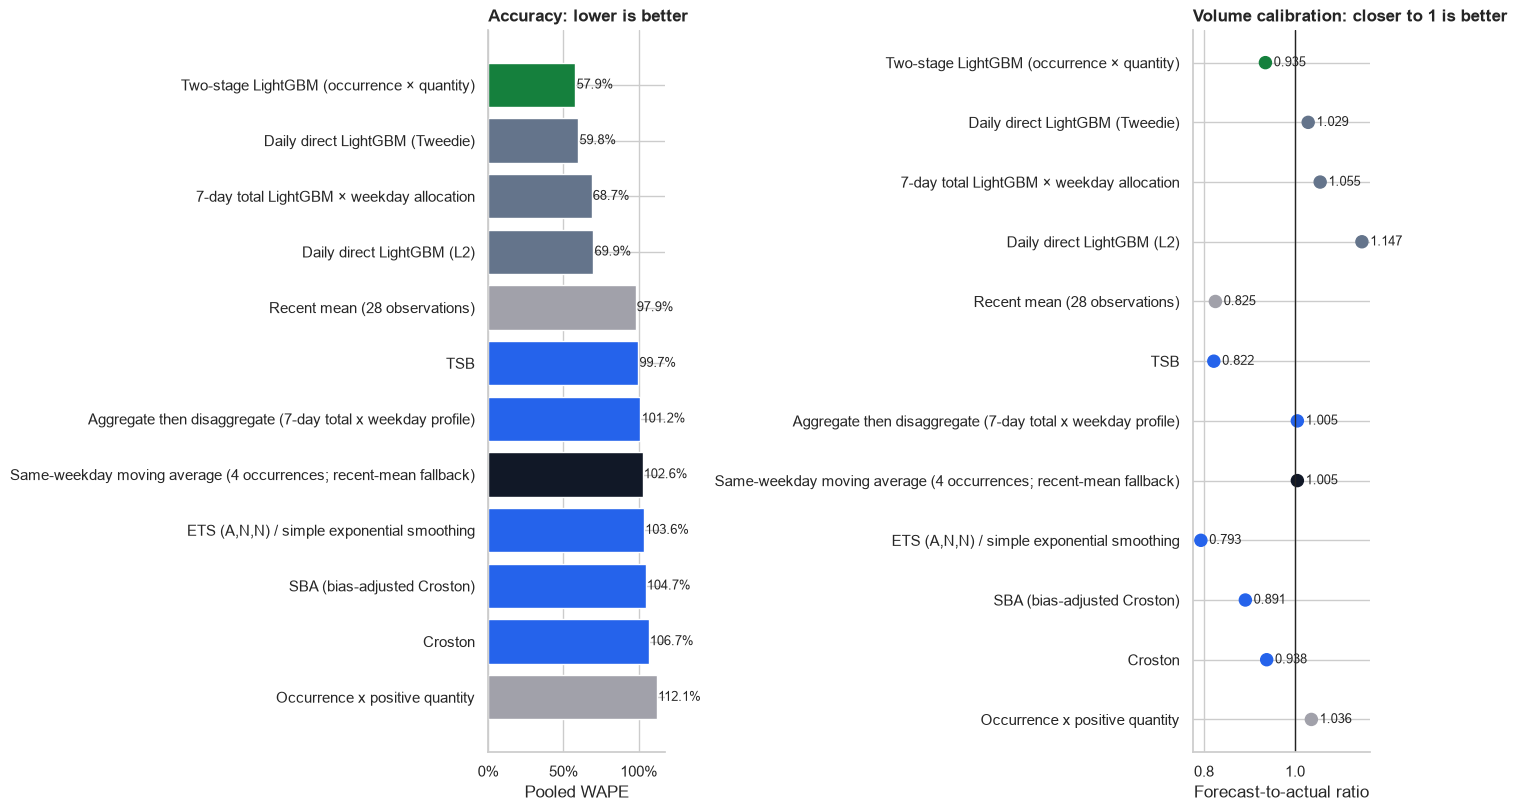

In [6]:
plot_summary = comparison_table.copy()
colors = [
    '#15803d' if model == ml_summary.iloc[0].model
    else '#64748b' if model in ML_MODELS
    else '#111827' if model == PRIMARY_MODEL
    else '#2563eb' if model in BASELINE_MODEL_LABELS
    else '#a1a1aa'
    for model in plot_summary.model
]
fig, axes = plt.subplots(1, 2, figsize=(14, 8), constrained_layout=True)
axes[0].barh(plot_summary.model_label, plot_summary.pooled_wape, color=colors)
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_xlabel('Pooled WAPE')
axes[0].set_ylabel('')
axes[0].set_title('Accuracy: lower is better', loc='left', weight='bold')
for y, value in enumerate(plot_summary.pooled_wape):
    axes[0].text(value + .008, y, f'{value:.1%}', va='center', fontsize=9)
axes[1].axvline(1, color='#222222', linewidth=1)
axes[1].scatter(plot_summary.forecast_to_actual_ratio, plot_summary.model_label, c=colors, s=75)
axes[1].invert_yaxis()
axes[1].set_xlabel('Forecast-to-actual ratio')
axes[1].set_ylabel('')
axes[1].set_title('Volume calibration: closer to 1 is better', loc='left', weight='bold')
for y, value in enumerate(plot_summary.forecast_to_actual_ratio):
    axes[1].annotate(f'{value:.3f}', (value, y), xytext=(6, 0), textcoords='offset points', va='center', fontsize=9)
sns.despine(fig=fig)
plt.show()

## Stability across origins

In [7]:
benchmark_origin_results = segment_wape(benchmark_forecasts, 'origin')
lightgbm_l2_origin_results = segment_wape(lightgbm_l2_forecasts, 'origin')
lightgbm_tweedie_origin_results = segment_wape(
    lightgbm_tweedie_forecasts, 'origin'
)
lightgbm_two_stage_origin_results = segment_wape(
    lightgbm_two_stage_forecasts, 'origin'
)
lightgbm_weekly_total_origin_results = segment_wape(
    lightgbm_weekly_total_forecasts, 'origin'
)
origin_results = pd.concat([
    benchmark_origin_results,
    lightgbm_l2_origin_results,
    lightgbm_tweedie_origin_results,
    lightgbm_two_stage_origin_results,
    lightgbm_weekly_total_origin_results,
], ignore_index=True)
origin_wide = origin_results.pivot(index='origin', columns='model', values='pooled_wape')
origin_rows = []
for model in ML_MODELS:
    delta = origin_wide[model] - origin_wide[best_reference.model]
    origin_rows.append({
        'model': model,
        'model_label': LIGHTGBM_MODEL_LABELS[model],
        'origins_won_vs_best_reference': delta.lt(0).sum(),
        'origins_evaluated': delta.notna().sum(),
        'mean_wape_delta_pp': 100 * delta.mean(),
        'worst_wape_delta_pp': 100 * delta.max(),
    })
origin_summary = pd.DataFrame(origin_rows).sort_values('mean_wape_delta_pp')
display(origin_summary.style.format({
    'origins_won_vs_best_reference': '{:,.0f}', 'origins_evaluated': '{:,.0f}',
    'mean_wape_delta_pp': '{:+.2f}', 'worst_wape_delta_pp': '{:+.2f}',
}))

,model,model_label,origins_won_vs_best_reference,origins_evaluated,mean_wape_delta_pp,worst_wape_delta_pp
2,global_lightgbm_two_stage,Two-stage LightGBM (occurrence × quantity),20,20,-40.25,-26.69
1,global_lightgbm_tweedie_daily,Daily direct LightGBM (Tweedie),20,20,-38.17,-25.99
3,global_lightgbm_weekly_total,7-day total LightGBM × weekday allocation,20,20,-29.06,-13.64
0,global_lightgbm,Daily direct LightGBM (L2),20,20,-27.89,-16.55


## Business segments: accuracy and forecast volume

The four requested reporting segments combine `sourcing_group` with `category_id`. Each segment shows the four LightGBM architectures, the fixed primary benchmark, the globally best extended baseline, and—if different—the globally best non-ML reference. Keeping the comparator fixed avoids selecting a different baseline after seeing each segment's test result. Actual kilograms are common across models; forecasted kilograms and the forecast-to-actual ratio expose each architecture's volume behavior.

In [8]:
benchmark_business = segment_wape(benchmark_forecasts, 'business_segment')
lightgbm_l2_business = segment_wape(
    lightgbm_l2_forecasts, 'business_segment'
)
lightgbm_tweedie_business = segment_wape(
    lightgbm_tweedie_forecasts, 'business_segment'
)
lightgbm_two_stage_business = segment_wape(
    lightgbm_two_stage_forecasts, 'business_segment'
)
lightgbm_weekly_total_business = segment_wape(
    lightgbm_weekly_total_forecasts, 'business_segment'
)
business = pd.concat([
    benchmark_business,
    lightgbm_l2_business,
    lightgbm_tweedie_business,
    lightgbm_two_stage_business,
    lightgbm_weekly_total_business,
], ignore_index=True)
business_reference = (
    business.loc[
        business.model.eq(best_reference.model),
        ['business_segment', 'pooled_wape'],
    ]
    .rename(columns={'pooled_wape': 'best_reference_wape'})
)
business_models = [
    *ML_MODELS, PRIMARY_MODEL, best_baseline.model, best_reference.model,
]
business_comparison = (
    business.loc[business.model.isin(business_models)]
    .merge(business_reference, on='business_segment', validate='m:1')
)
business_comparison['model_label'] = business_comparison.model.map(MODEL_LABELS)
business_comparison['forecasted_kg'] = (
    business_comparison.actual_kg * business_comparison.forecast_to_actual_ratio
)
business_comparison['gain_vs_best_reference_pp'] = 100 * (
    business_comparison.best_reference_wape - business_comparison.pooled_wape
)
business_comparison = business_comparison.sort_values(
    ['business_segment', 'pooled_wape']
)
display(business_comparison[[
    'business_segment', 'model_label', 'pooled_wape',
    'forecast_to_actual_ratio', 'actual_kg', 'forecasted_kg',
    'gain_vs_best_reference_pp',
]].style.format({
    'pooled_wape': '{:.2%}', 'forecast_to_actual_ratio': '{:.3f}',
    'actual_kg': '{:,.1f}', 'forecasted_kg': '{:,.1f}',
    'gain_vs_best_reference_pp': '{:+.2f}',
}))

,business_segment,model_label,pooled_wape,forecast_to_actual_ratio,actual_kg,forecasted_kg,gain_vs_best_reference_pp
20,FCM 890,Two-stage LightGBM (occurrence × quantity),162.16%,1.245,"3,840.1","4,779.5",+23.97
16,FCM 890,Daily direct LightGBM (Tweedie),164.96%,1.303,"3,840.1","5,003.9",+21.17
2,FCM 890,TSB,173.73%,1.184,"3,840.1","4,547.2",+12.40
24,FCM 890,7-day total LightGBM × weekday allocation,177.90%,1.364,"3,840.1","5,238.6",+8.23
0,FCM 890,Recent mean (28 observations),186.13%,1.299,"3,840.1","4,986.6",+0.00
1,FCM 890,Same-weekday moving average (4 occurrences; recent-mean fallback),198.85%,1.605,"3,840.1","6,161.9",-12.72
12,FCM 890,Daily direct LightGBM (L2),199.21%,1.592,"3,840.1","6,115.2",-13.08
21,FCM 900,Two-stage LightGBM (occurrence × quantity),80.13%,0.885,"56,737.4","50,196.2",+13.90
17,FCM 900,Daily direct LightGBM (Tweedie),85.29%,1.049,"56,737.4","59,521.8",+8.74
13,FCM 900,Daily direct LightGBM (L2),90.43%,1.104,"56,737.4","62,658.4",+3.60


## Why the architectures differ

In [9]:
def make_error_decomposition(forecasts):
    diagnostic = forecasts.copy()
    diagnostic['abs_error'] = (
        diagnostic.forecast - diagnostic.actual
    ).abs()
    diagnostic['zero_target_error'] = np.where(
        diagnostic.actual.eq(0), diagnostic.abs_error, 0.0
    )
    diagnostic['positive_target_error'] = np.where(
        diagnostic.actual.gt(0), diagnostic.abs_error, 0.0
    )
    return pd.DataFrame([{
        'model': diagnostic.model.iloc[0],
        'actual_kg': diagnostic.actual.sum(),
        'forecasted_kg': diagnostic.forecast.sum(),
        'absolute_error_kg': diagnostic.abs_error.sum(),
        'error_on_zero_targets_kg': diagnostic.zero_target_error.sum(),
        'error_on_positive_targets_kg': diagnostic.positive_target_error.sum(),
        'near_zero_forecast_share': diagnostic.forecast.le(1e-8).mean(),
    }])

lightgbm_l2_error = make_error_decomposition(lightgbm_l2_forecasts)
lightgbm_tweedie_error = make_error_decomposition(lightgbm_tweedie_forecasts)
lightgbm_two_stage_error = make_error_decomposition(
    lightgbm_two_stage_forecasts
)
lightgbm_weekly_total_error = make_error_decomposition(
    lightgbm_weekly_total_forecasts
)
error_decomposition = pd.concat([
    lightgbm_l2_error,
    lightgbm_tweedie_error,
    lightgbm_two_stage_error,
    lightgbm_weekly_total_error,
], ignore_index=True)
error_decomposition['model_label'] = error_decomposition.model.map(LIGHTGBM_MODEL_LABELS)
error_decomposition['forecast_to_actual_ratio'] = error_decomposition.forecasted_kg / error_decomposition.actual_kg
error_decomposition['zero_target_error_share'] = error_decomposition.error_on_zero_targets_kg / error_decomposition.absolute_error_kg
display(error_decomposition[[
    'model_label', 'actual_kg', 'forecasted_kg', 'forecast_to_actual_ratio',
    'absolute_error_kg', 'error_on_zero_targets_kg',
    'error_on_positive_targets_kg', 'zero_target_error_share',
    'near_zero_forecast_share',
]].sort_values('absolute_error_kg').style.format({
    'actual_kg': '{:,.1f}', 'forecasted_kg': '{:,.1f}',
    'forecast_to_actual_ratio': '{:.3f}', 'absolute_error_kg': '{:,.1f}',
    'error_on_zero_targets_kg': '{:,.1f}', 'error_on_positive_targets_kg': '{:,.1f}',
    'zero_target_error_share': '{:.1%}', 'near_zero_forecast_share': '{:.1%}',
}))

,model_label,actual_kg,forecasted_kg,forecast_to_actual_ratio,absolute_error_kg,error_on_zero_targets_kg,error_on_positive_targets_kg,zero_target_error_share,near_zero_forecast_share
2,Two-stage LightGBM (occurrence × quantity),"2,552,925.9","2,386,921.0",0.935,"1,478,567.3","241,390.6","1,237,176.8",16.3%,0.0%
1,Daily direct LightGBM (Tweedie),"2,552,925.9","2,626,763.4",1.029,"1,527,570.4","279,962.5","1,247,607.9",18.3%,0.0%
3,7-day total LightGBM × weekday allocation,"2,552,925.9","2,693,908.2",1.055,"1,754,642.8","379,290.0","1,375,352.7",21.6%,11.7%
0,Daily direct LightGBM (L2),"2,552,925.9","2,928,040.5",1.147,"1,783,970.6","452,593.4","1,331,377.2",25.4%,0.3%


Daily direct LightGBM (L2)


,stage,feature,gain_share,splits
15,single model,demand_day_ratio,16.6%,221
0,single model,ADI,15.2%,222
2,single model,CV2,13.8%,69
26,single model,iso_week,8.7%,578
24,single model,historical_p90_gap,7.1%,74


Daily direct LightGBM (Tweedie)


,stage,feature,gain_share,splits
5,single model,action_on_forecast_day,33.4%,655
1,single model,ARTIKEL_ID,18.0%,"7,062"
4,single model,action_during_horizon,10.7%,447
10,single model,current_gap_over_historical_p90_gap,6.4%,350
0,single model,ADI,4.9%,424


Two-stage LightGBM (occurrence × quantity)


,stage,feature,gain_share,splits
5,occurrence,action_on_forecast_day,31.6%,189
70,positive_quantity,demand_day_ratio,20.6%,195
56,positive_quantity,ARTIKEL_ID,19.1%,"4,258"
55,positive_quantity,ADI,17.5%,199
17,occurrence,demand_days_last_28,17.2%,131
60,positive_quantity,action_on_forecast_day,15.7%,359
18,occurrence,demand_days_last_60,12.7%,223
40,occurrence,rolling_28_demand_rate,7.5%,172
4,occurrence,action_during_horizon,6.5%,321
81,positive_quantity,iso_week,5.2%,"2,911"


7-day total LightGBM × weekday allocation


,stage,feature,gain_share,splits
5,single model,action_on_forecast_day,40.5%,571
1,single model,ARTIKEL_ID,19.9%,"3,017"
10,single model,current_gap_over_historical_p90_gap,7.7%,233
0,single model,ADI,6.1%,298
12,single model,demand_day_ratio,5.9%,309


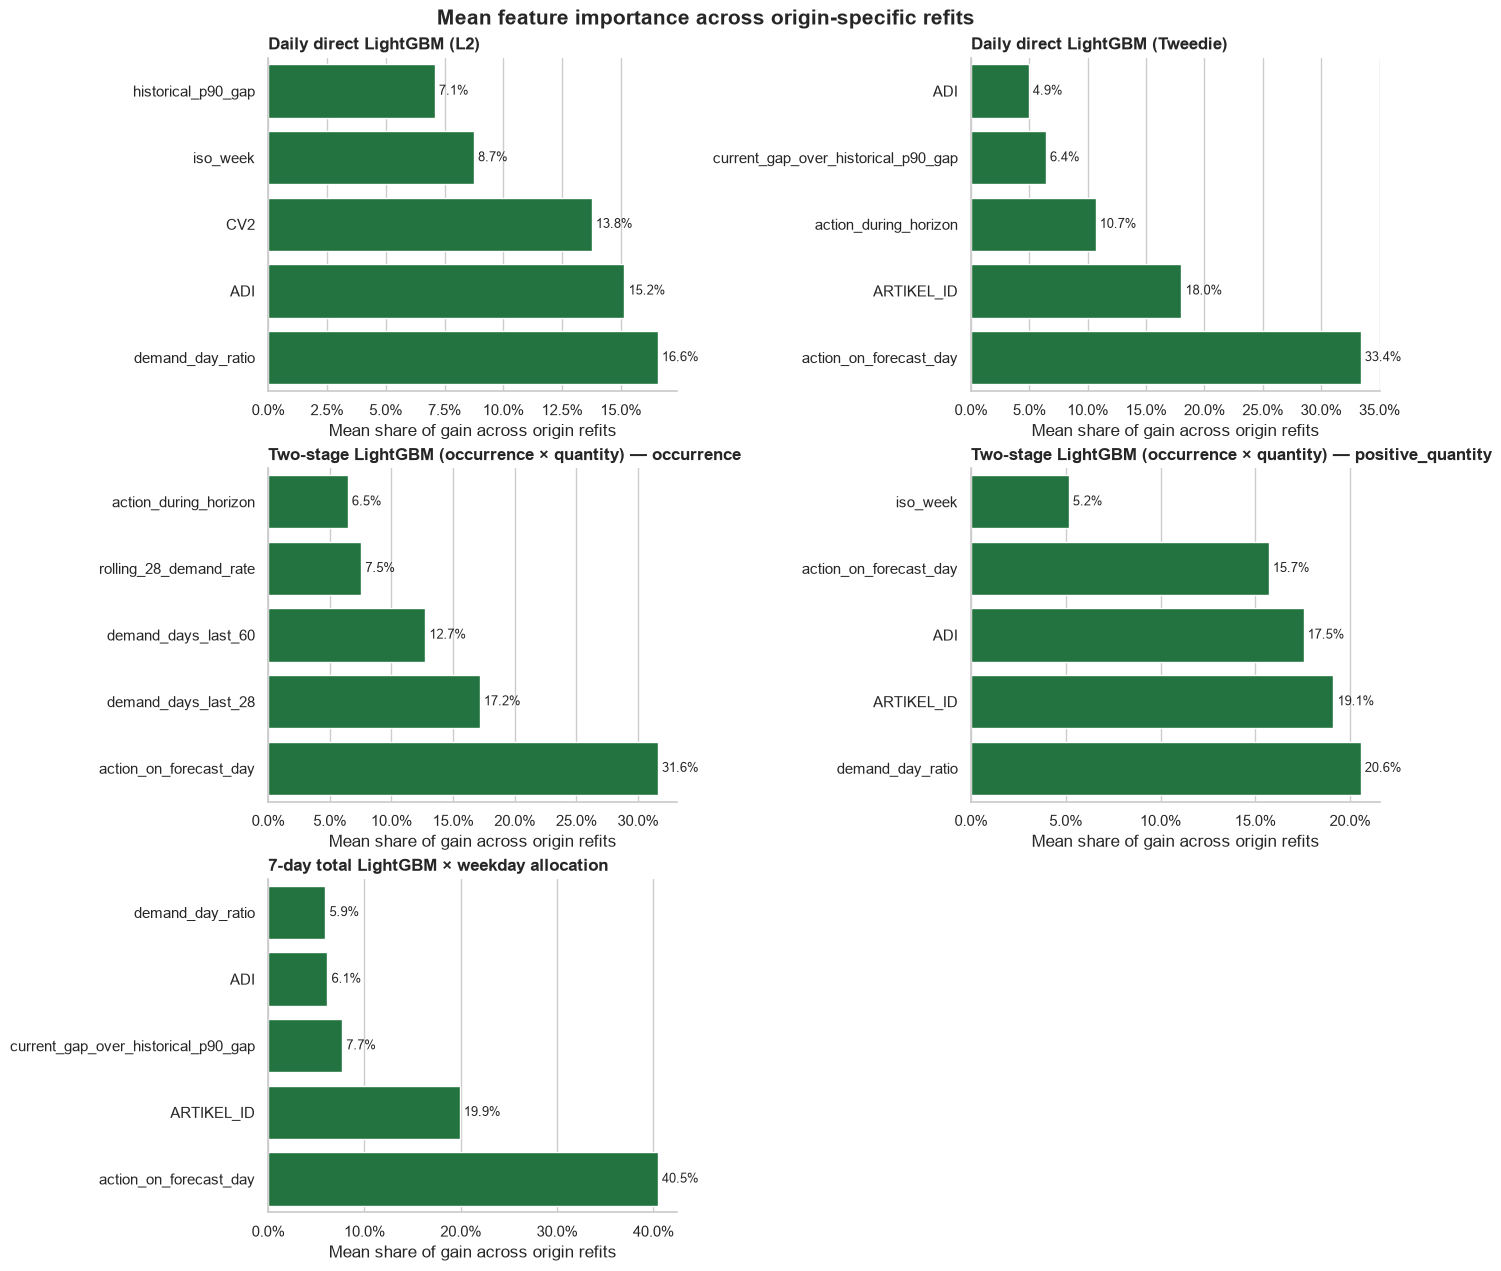

In [10]:
def summarize_feature_importance(frame, model):
    importance = frame.copy()
    if 'stage' not in importance:
        importance['stage'] = 'single model'
    importance = (
        importance.groupby(['stage', 'feature'], observed=True)
        .agg(gain_share=('gain_share', 'mean'), splits=('splits', 'mean'))
        .reset_index()
    )
    importance['model'] = model
    importance['model_label'] = LIGHTGBM_MODEL_LABELS[model]
    return (
        importance.sort_values('gain_share', ascending=False)
        .groupby('stage', observed=True).head(5)
    )

lightgbm_l2_top_importance = summarize_feature_importance(
    lightgbm_l2_feature_importance, MODEL_NAME
)
lightgbm_tweedie_top_importance = summarize_feature_importance(
    lightgbm_tweedie_feature_importance, TWEEDIE_MODEL_NAME
)
lightgbm_two_stage_top_importance = summarize_feature_importance(
    lightgbm_two_stage_feature_importance, TWO_STAGE_MODEL_NAME
)
lightgbm_weekly_total_top_importance = summarize_feature_importance(
    lightgbm_weekly_total_feature_importance, WEEKLY_MODEL_NAME
)
TOP_IMPORTANCE_FRAMES = {
    MODEL_NAME: lightgbm_l2_top_importance,
    TWEEDIE_MODEL_NAME: lightgbm_tweedie_top_importance,
    TWO_STAGE_MODEL_NAME: lightgbm_two_stage_top_importance,
    WEEKLY_MODEL_NAME: lightgbm_weekly_total_top_importance,
}
for model, top_importance in TOP_IMPORTANCE_FRAMES.items():
    print(LIGHTGBM_MODEL_LABELS[model])
    display(top_importance[[
        'stage', 'feature', 'gain_share', 'splits',
    ]].style.format({'gain_share': '{:.1%}', 'splits': '{:,.0f}'}))

importance_panels = []
for model, top_importance in TOP_IMPORTANCE_FRAMES.items():
    for stage, panel in top_importance.groupby('stage', sort=False, observed=True):
        importance_panels.append(
            ((LIGHTGBM_MODEL_LABELS[model], stage), panel)
        )
ncols = 2
nrows = int(np.ceil(len(importance_panels) / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(14, 4.2 * nrows), squeeze=False,
    constrained_layout=True,
)
for ax, ((model_label, stage), panel) in zip(axes.flat, importance_panels):
    panel = panel.sort_values('gain_share', ascending=True)
    sns.barplot(
        data=panel, x='gain_share', y='feature',
        color='#15803d', ax=ax,
    )
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel('Mean share of gain across origin refits')
    ax.set_ylabel('')
    stage_suffix = '' if stage == 'single model' else f' — {stage}'
    ax.set_title(f'{model_label}{stage_suffix}', loc='left', weight='bold')
    ax.bar_label(
        ax.containers[0], labels=[f'{value:.1%}' for value in panel.gain_share],
        padding=3, fontsize=9,
    )
for ax in axes.flat[len(importance_panels):]:
    ax.set_visible(False)
fig.suptitle(
    'Mean feature importance across origin-specific refits',
    fontsize=15, weight='bold',
)
sns.despine(fig=fig)
plt.show()

In [11]:
weekly_audit = lightgbm_weekly_total_allocation_audit
allocation_summary = pd.DataFrame([{
    'series_origins': len(weekly_audit),
    'max_allocation_error_kg': weekly_audit.allocation_error.max(),
    'max_weekday_share_deviation': (weekly_audit.weekday_share_sum - 1).abs().max(),
}])
display(allocation_summary.style.format({
    'series_origins': '{:,.0f}', 'max_allocation_error_kg': '{:.3e}',
    'max_weekday_share_deviation': '{:.3e}',
}))

,series_origins,max_allocation_error_kg,max_weekday_share_deviation
0,"435,939",1.137e-13,4.441e-16
